In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib

In [16]:
df = pd.read_csv("data/processed/delhi_cleaned.csv")

df['datetime'] = pd.to_datetime(df['datetime'])

prophet_df = df[['datetime','aqi']]

prophet_df.columns = ['ds','y']

prophet_df.head()

,ds,y
0,2020-01-01 06:00:00,500
1,2020-01-01 12:00:00,500
2,2020-01-01 18:00:00,500
3,2020-01-01 23:00:00,500
4,2020-01-01 06:00:00,500


In [17]:
split = int(len(prophet_df)*0.8)

train = prophet_df[:split]

test = prophet_df[split:]

In [18]:
model = Prophet(

yearly_seasonality=True,

weekly_seasonality=True,

daily_seasonality=True

)

In [19]:
model.fit(train)

print("Prophet Model Trained")

16:40:15 - cmdstanpy - INFO - Chain [1] start processing
16:40:43 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Trained


In [20]:
future = test[['ds']]

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-10-19 06:00:00,366.331524,404.120771,522.038018,366.331524,366.331524,97.734163,97.734163,97.734163,-99.037759,...,-3.568065,-3.568065,-3.568065,200.339987,200.339987,200.339987,0.0,0.0,0.0,464.065687
1,2024-10-19 06:00:00,366.331524,404.640262,525.159341,366.331524,366.331524,97.734163,97.734163,97.734163,-99.037759,...,-3.568065,-3.568065,-3.568065,200.339987,200.339987,200.339987,0.0,0.0,0.0,464.065687
2,2024-10-19 06:00:00,366.331524,404.613665,519.744049,366.331524,366.331524,97.734163,97.734163,97.734163,-99.037759,...,-3.568065,-3.568065,-3.568065,200.339987,200.339987,200.339987,0.0,0.0,0.0,464.065687
3,2024-10-19 06:00:00,366.331524,405.906622,520.192903,366.331524,366.331524,97.734163,97.734163,97.734163,-99.037759,...,-3.568065,-3.568065,-3.568065,200.339987,200.339987,200.339987,0.0,0.0,0.0,464.065687
4,2024-10-19 06:00:00,366.331524,406.694459,520.675692,366.331524,366.331524,97.734163,97.734163,97.734163,-99.037759,...,-3.568065,-3.568065,-3.568065,200.339987,200.339987,200.339987,0.0,0.0,0.0,464.065687


In [21]:
y_true = test['y']

y_pred = forecast['yhat']


r2 = r2_score(

    y_true,

    y_pred

)


mae = mean_absolute_error(

    y_true,

    y_pred

)


mse = mean_squared_error(

    y_true,

    y_pred

)


rmse = np.sqrt(mse)



print("R² :", r2)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

R² : 0.9265097662656283
MAE : 36.92731256753004
MSE : 2346.180508072871
RMSE : 48.43738750255706


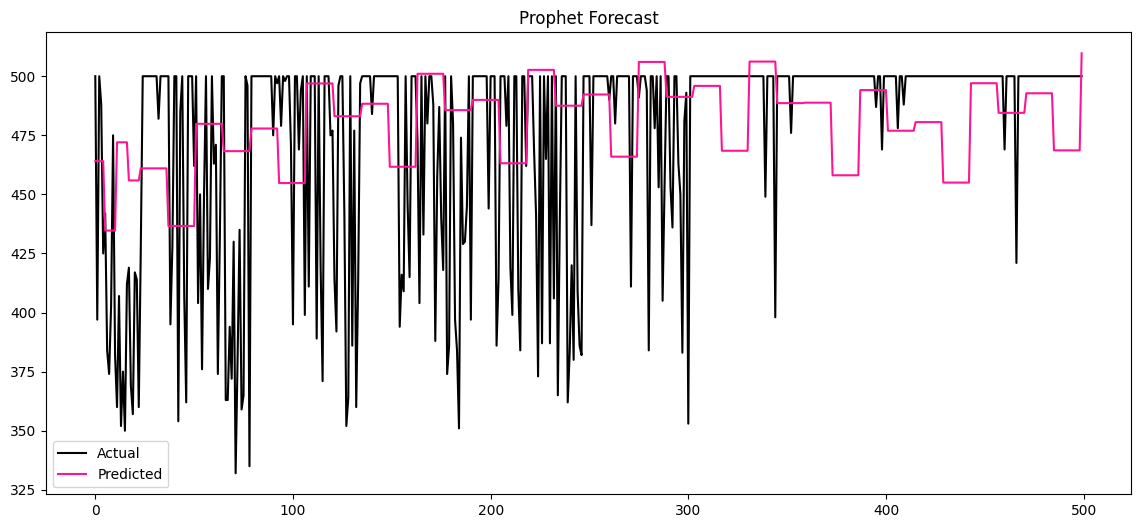

In [22]:
plt.figure(figsize=(14,6))


plt.plot(

    y_true.values[:500],

    color='black',

    label='Actual'

)


plt.plot(

    y_pred.values[:500],

    color='deeppink',

    label='Predicted'

)



plt.title(

    "Prophet Forecast"

)

plt.legend()


plt.show()

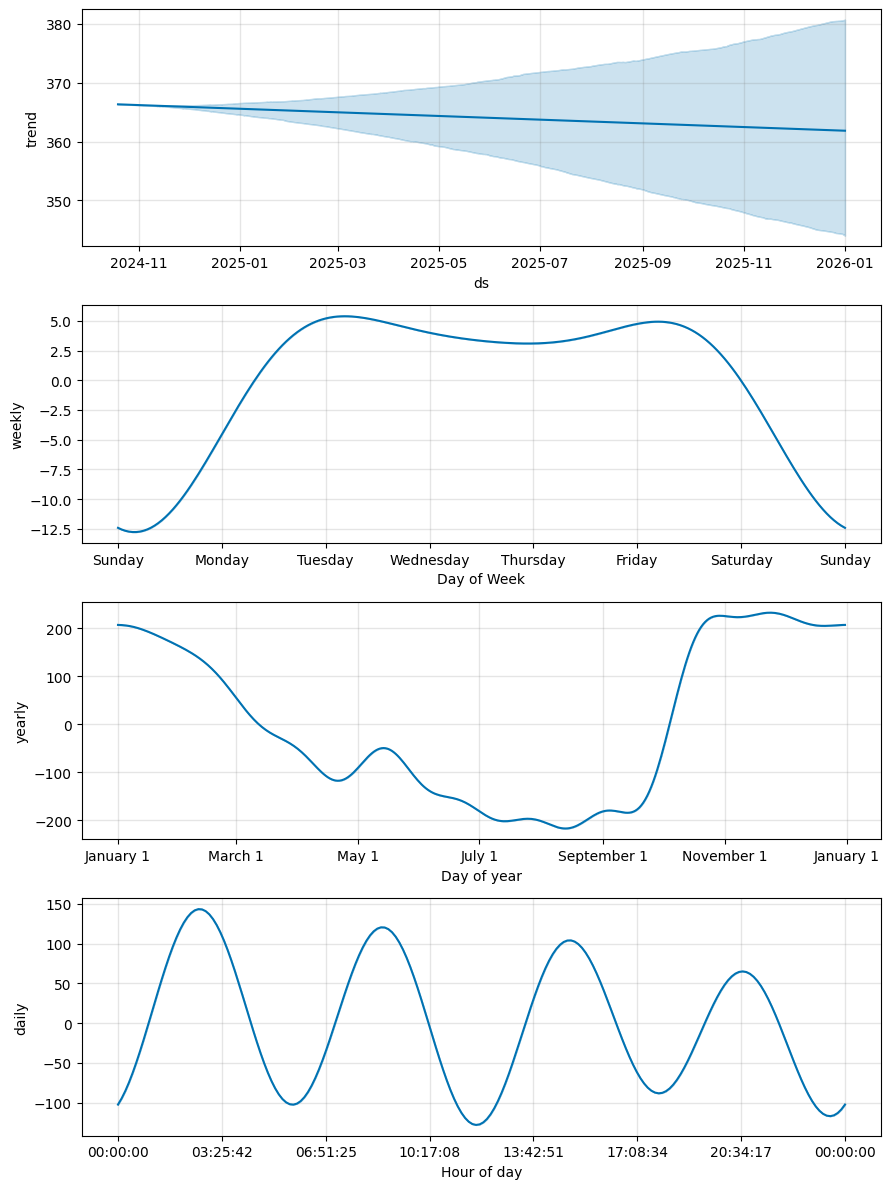

In [23]:
fig = model.plot_components(

    forecast

)

plt.show()

In [25]:
joblib.dump(

    model,

    "models/prophet.pkl"

)


print("✅ Prophet Model Saved")

✅ Prophet Model Saved
